# Preprocessing external dataset: Hayashi et al. (2026)

In [ ]:
import os
import gzip
import glob
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
from sklearn_ann.kneighbors.annoy import AnnoyTransformer
from scipy import sparse

np.random.seed(42)

Source data downloaded from GEO (accession GSE133028 and GSE291328)

# Load and preprocess data

Load TCR data to identify paired GEX samples

In [2]:
tcr = pd.read_csv(
    "../data/processed/external/hayashi/source/GSE291328_Processed_data_allTCR.csv.gz",
    header=0,
    index_col=0,
)
tcr[["Paper_ID", "Diagnosis", "loc"]] = tcr["Paper_ID_Diagnosis_loc"].str.split("_", n=2, expand=True)

In [4]:
samples = tcr[["Patient_ID", "Paper_ID", "Diagnosis", "loc"]].drop_duplicates().query("Diagnosis in ['RRMS', 'CIS', 'HC']").reset_index(drop=True).rename(
    columns={
        "Patient_ID": "donor_alt",
        "Paper_ID": "donor",
        "Diagnosis": "diagnosis",
        "loc": "organ"
    }
)
samples["sample_id"] = [f"{donor}_{diagnosis}_{organ}" for donor, diagnosis, organ in zip(samples["donor"], samples["diagnosis"], samples["organ"])]
samples = samples.set_index("sample_id", drop=False)
samples

,donor_alt,donor,diagnosis,organ,sample_id
sample_id,,,,,
24_RRMS_PB,88418b,24,RRMS,PB,24_RRMS_PB
22_CIS_PB,91618a,22,CIS,PB,22_CIS_PB
25_RRMS_PB,88618a,25,RRMS,PB,25_RRMS_PB
6_RRMS_PB,87917a,6,RRMS,PB,6_RRMS_PB
28_RRMS_CSF,90218a,28,RRMS,CSF,28_RRMS_CSF
7_RRMS_PB,90118a,7,RRMS,PB,7_RRMS_PB
10_RRMS_PB,92418a,10,RRMS,PB,10_RRMS_PB
27_RRMS_PB,88818a,27,RRMS,PB,27_RRMS_PB
29_RRMS_PB,91518a,29,RRMS,PB,29_RRMS_PB


In [5]:
files = {row["sample_id"]: glob.glob(f"../data/processed/external/hayashi/source/*_{row['donor']}_*_{row['organ']}_*.csv.gz")[0] for _, row in samples.iterrows() if glob.glob(f"../data/processed/external/hayashi/source/*_{row['donor']}_*_{row['organ']}_*.csv.gz")}
files

{'24_RRMS_PB': '../data/processed/external/hayashi/source/GSM5264658_24_t2_PB_uns_5pGEX.rawCounts.csv.gz',
 '22_CIS_PB': '../data/processed/external/hayashi/source/GSM5264656_22_t1_PB_uns_5pGEX.rawCounts.csv.gz',
 '25_RRMS_PB': '../data/processed/external/hayashi/source/GSM5264660_25_t1_PB_uns_5pGEX.rawCounts.csv.gz',
 '6_RRMS_PB': '../data/processed/external/hayashi/source/GSM5264640_6_t1_PB_uns_5pGEX.rawCounts.csv.gz',
 '28_RRMS_CSF': '../data/processed/external/hayashi/source/GSM5264663_28_t1_CSF_uns_5pGEX.rawCounts.csv.gz',
 '7_RRMS_PB': '../data/processed/external/hayashi/source/GSM5264642_7_t1_PB_uns_5pGEX.rawCounts.csv.gz',
 '10_RRMS_PB': '../data/processed/external/hayashi/source/GSM5264648_10_t1_PB_uns_5pGEX.rawCounts.csv.gz',
 '27_RRMS_PB': '../data/processed/external/hayashi/source/GSM5264662_27_t1_PB_uns_5pGEX.rawCounts.csv.gz',
 '29_RRMS_PB': '../data/processed/external/hayashi/source/GSM5264666_29_t1_PB_uns_5pGEX.rawCounts.csv.gz',
 '27_RRMS_CSF': '../data/processed/exter

Load sample metadata

In [6]:
md = pd.read_excel(
    "../data/processed/external/hayashi/source/pnas.2008523117.sd01.xlsx",
    sheet_name="Dataset S1A",
    header=1,
    index_col=None,
    skiprows=0,
    nrows=24,
    usecols=["Subject ID", "Age", "Sex", "Diagnosis", "EDSS", "Treatment", "months from onset", "5' or 3' 10x Library Kit"],
    dtype={"Subject ID": str}
).rename(
    columns={
        "Subject ID": "donor",
        "Age": "age",
        "Sex": "sex",
        "Diagnosis": "diagnosis",
        "EDSS": "edss",
        "Treatment": "treatment",
        "months from onset": "disease_duration",
        "5' or 3' 10x Library Kit": "chemistry"
    }
).query("diagnosis in ['RRMS', 'CIS', 'HC']").assign(
    disease=lambda df: np.where(df["diagnosis"] == "HC", "HC", "MS/CIS")
)
md = md.set_index("donor")
md

,age,sex,diagnosis,edss,treatment,disease_duration,chemistry,disease
donor,,,,,,,,
1,43,F,RRMS,0.0,Untreated,16.0,5',MS/CIS
2,33,M,HC,NaN,Untreated,NaN,5',HC
3,27,F,HC,NaN,Untreated,NaN,5',HC
6,44,M,RRMS,2.0,Untreated,1.0,5',MS/CIS
7,37,M,RRMS,1.5,Untreated,14.0,5',MS/CIS
8,32,M,RRMS,1.5,Untreated,4.0,5',MS/CIS
9,27,F,RRMS,3.5,Untreated,27.0,5',MS/CIS
10,45,F,RRMS,2.0,Untreated,3.0,5',MS/CIS
16,22,M,RRMS,4.0,Untreated,0.0,3',MS/CIS


Load raw counts

In [7]:
def load_csv_to_sparse(filepath):
    """
    Load compressed CSV dense matrix to sparse matrix
    """
    row_indices = []
    col_indices = []
    data = []
    row_names = []

    with gzip.open(filepath, 'rt') as f:
        col_names = f.readline().strip().split(',')

        row_idx = 0
        for line in f:
            row = line.strip().split(',')
            row_name = row[0]
            row_names.append(row_name)

            values = [float(x) if x else 0.0 for x in row[1:]]
            for col_idx, val in enumerate(values):
                if val > 0.0:
                    row_indices.append(row_idx)
                    col_indices.append(col_idx)
                    data.append(val)

            row_idx += 1

    mat = sparse.csr_matrix(
        (data, (row_indices, col_indices)),
        shape=(len(row_names), len(col_names)),
        dtype=float
    )

    return mat, row_names, col_names

In [ ]:
adata_dict = {}
for id, file in files.items():
    counts, var_names, obs_names = load_csv_to_sparse(file)
    counts = counts.transpose()
    obs = pd.DataFrame(index=obs_names)
    var = pd.DataFrame(index=var_names)
    adata_dict[id] = ad.AnnData(X=counts, obs=obs, var=var)
adata = ad.concat(adata_dict, label="sample_id", index_unique=None)
adata.obs = adata.obs.join(samples[["donor", "donor_alt", "organ"]], on="sample_id", how="left")
adata.obs = adata.obs.join(md, on="donor", how="left")
adata.obs["barcode_alt"] = [f"{barcode.split('-')[0]}-{donor_alt}_{organ}_uns" for barcode, donor_alt, organ in zip(adata.obs.index, adata.obs["donor_alt"], adata.obs["organ"])]
adata.obs["barcode"] = adata.obs.index
adata.obs = adata.obs.set_index(adata.obs["barcode_alt"])
adata.obs.index.name = None
adata.obs["organ"] = adata.obs["organ"].replace({"PB": "PBMC"})

In [65]:
adata

AnnData object with n_obs × n_vars = 120573 × 33538
    obs: 'sample_id', 'donor', 'donor_alt', 'organ', 'age', 'sex', 'diagnosis', 'edss', 'treatment', 'disease_duration', 'chemistry', 'disease', 'barcode_alt', 'barcode'

Standardise gene names across datasets and aggregate counts for alias genes in original count matrix

In [67]:
translation = pd.read_csv("../data/processed/external/hayashi/source/hayashi_genes_translation.tsv", sep="\t", header=0, index_col="original_gene_symbol")
translation.index.name = None

adata = adata[:, translation.index].copy()
adata.var = translation.copy()

grouped = translation.groupby('ensembl_id')
n_original_genes = adata.n_vars
unique_ensembl_ids = translation['ensembl_id'].unique()
n_unique_genes = len(unique_ensembl_ids)
ensembl_to_new_idx = {ensembl_id: i for i, ensembl_id in enumerate(unique_ensembl_ids)}

row_indices = []
col_indices = []
data = []

for old_idx, (ensembl_id, gene_symbol) in enumerate(zip(translation['ensembl_id'], translation['gene_symbol'])):
    new_idx = ensembl_to_new_idx[ensembl_id]
    row_indices.append(new_idx)
    col_indices.append(old_idx)
    data.append(1.0)

aggregation_matrix = sparse.csr_matrix(
    (data, (row_indices, col_indices)), 
    shape=(n_unique_genes, n_original_genes)
)

X_aggregated = (aggregation_matrix @ adata.X.T).T

new_var = pd.DataFrame(index=unique_ensembl_ids)
new_var['ensembl_id'] = unique_ensembl_ids
new_var['gene_symbol'] = [grouped.get_group(ensembl_id)['gene_symbol'].iloc[0] 
                          for ensembl_id in unique_ensembl_ids]
new_var['gene_type'] = [grouped.get_group(ensembl_id)['gene_type'].iloc[0]
                        for ensembl_id in unique_ensembl_ids]
new_var.index = new_var['gene_symbol']
new_var.index.name = None

adata = ad.AnnData(
    X=X_aggregated,
    obs=adata.obs.copy(),
    var=new_var
)
adata.var_names_make_unique()

sc.pp.filter_genes(adata, min_cells=1)

/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/python3.11/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [68]:
# Store raw counts for use with starCAT
adata.raw = adata
adata

AnnData object with n_obs × n_vars = 120573 × 18333
    obs: 'sample_id', 'donor', 'donor_alt', 'organ', 'age', 'sex', 'diagnosis', 'edss', 'treatment', 'disease_duration', 'chemistry', 'disease', 'barcode_alt', 'barcode'
    var: 'ensembl_id', 'gene_symbol', 'gene_type', 'n_cells'

# Normalise, find variable features across datasets and integrate

Load cell cycle genes

In [69]:
with open("/project/fuggerlab/rfarooq/ref/genes/g2m_genes.txt") as f:
    g2m_genes = f.read().splitlines()
    g2m_genes = [gene for gene in g2m_genes if gene in adata.var_names]

with open("/project/fuggerlab/rfarooq/ref/genes/s_genes.txt") as f:
    s_genes = f.read().splitlines()
    s_genes = [gene for gene in s_genes if gene in adata.var_names]

In [70]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes)
sc.pp.highly_variable_genes(adata, n_top_genes=5000, batch_key="sample_id")
# Exclude mitochondrial and ribosomal genes from highly variable features
mito_genes = adata.var_names.str.startswith("MT-")
ribo_genes = adata.var_names.str.startswith(("RPS", "RPL"))
exclude_genes = mito_genes | ribo_genes
adata.var.loc[exclude_genes, "highly_variable"] = False
adata = adata[:, adata.var.highly_variable].copy()
sc.pp.regress_out(adata, keys=["S_score", "G2M_score"], n_jobs=16)
sc.pp.scale(adata, max_value=10)
sc.pp.pca(adata, n_comps=50, svd_solver="arpack")
sc.external.pp.harmony_integrate(adata, key=["sample_id"], max_iter_harmony=50)

2026-06-22 16:39:20,868 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-06-22 16:39:30,077 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-06-22 16:39:30,601 - harmonypy - INFO - Iteration 1 of 50
2026-06-22 16:40:16,506 - harmonypy - INFO - Iteration 2 of 50
2026-06-22 16:40:58,147 - harmonypy - INFO - Iteration 3 of 50
2026-06-22 16:41:35,523 - harmonypy - INFO - Iteration 4 of 50
2026-06-22 16:42:11,386 - harmonypy - INFO - Iteration 5 of 50
2026-06-22 16:42:47,122 - harmonypy - INFO - Iteration 6 of 50
2026-06-22 16:43:21,837 - harmonypy - INFO - Iteration 7 of 50
2026-06-22 16:43:54,054 - harmonypy - INFO - Iteration 8 of 50
2026-06-22 16:44:17,772 - harmonypy - INFO - Iteration 9 of 50
2026-06-22 16:44:49,520 - harmonypy - INFO - Iteration 10 of 50
2026-06-22 16:45:12,437 - harmonypy - INFO - Iteration 11 of 50
2026-06-22 16:45:40,806 - harmonypy - INFO - Iteration 12 of 50
2026-06-22 16:46:05,168 - harmonypy - INFO - Converged after

In [71]:
sc.pp.neighbors(adata, transformer=AnnoyTransformer(n_neighbors=30, metric="angular"), use_rep="X_pca_harmony")
sc.tl.umap(adata)

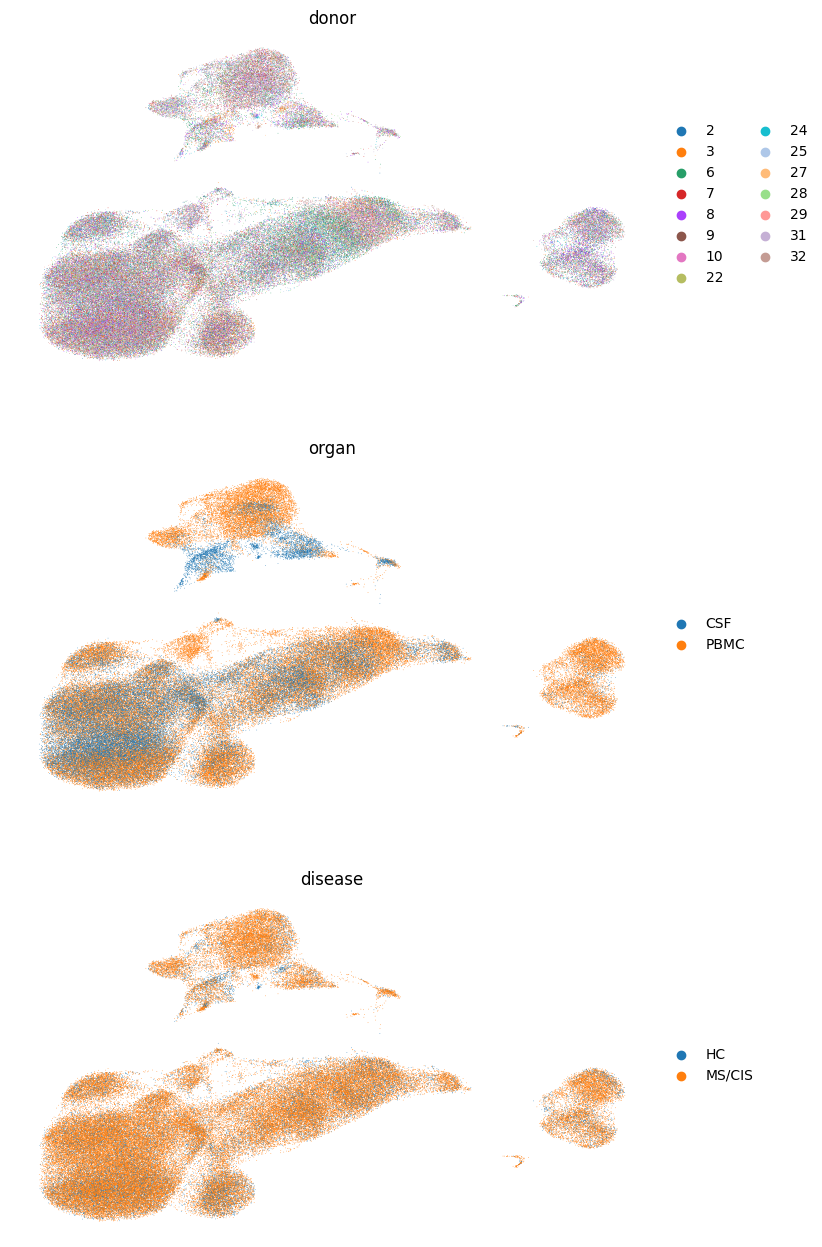

In [72]:
sc.pl.umap(adata, color=["donor", "organ", "disease"], wspace=0.4, frameon=False, ncols=1)

In [ ]:
# Save processed data
os.makedirs("../data/processed/external/hayashi/annotated", exist_ok=True)
adata.write_h5ad("../data/processed/external/hayashi/annotated/hayashi_ms_hc_full.h5ad")